<a href="https://colab.research.google.com/github/preethipalanisamy12-source/AlmaBetter-Projects/blob/main/EDA_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -

# **SupplyChain Pulse: Decoding Global Health Commodity Delivery Through EDA**
An Exploratory Data Analysis of SCMS Delivery History to Drive Efficiency, Reduce Costs, and Accelerate Life-Saving Shipments Across 43 Countries.

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Analysed by**     - Preethi P

# **Project Summary -**

The SCMS (Supply Chain Management System) Delivery History dataset captures 10,324 shipment records spanning **2006–2015**, documenting the **global distribution** of HIV/AIDS antiretroviral medications, diagnostic test kits, malaria treatments, and antimalarial drugs across **43 countries** — primarily across Sub-Saharan Africa, with additional shipments to South and Southeast Asia, the Caribbean, and Latin America.
Each record tracks the complete journey of a commodity from procurement request to client delivery, including vendor identity, shipment mode (Air, Air Charter, Truck, Ocean), scheduled vs. actual delivery dates, freight costs, insurance, pack pricing, unit pricing, and manufacturing origin. With **73 distinct vendors** — predominantly Indian pharmaceutical manufacturers — and over **1.63 billion dollars in total shipment value**, this dataset represents a live window into one of the world's most critical humanitarian supply chains.
The core objective of this EDA is to **help FedEx Logistics streamline operations** by surfacing patterns that answer three high-impact business questions: Where are deliveries being delayed, and why? Which shipment modes and vendors deliver the best cost efficiency? And What trends, correlations, and outliers in the data point to systemic supply chain improvements that can lower costs and improve delivery reliability for millions of patients worldwide.

# **GitHub Link -**

https://github.com/preethipalanisamy12-source/AlmaBetter-Projects.git

# **Problem Statement**


**Write Problem Statement Here.**

FedEx Logistics operates a complex global supply chain where maintaining delivery timelines and cost-effectiveness is critical for a competitive advantage. However, the current logistics process indicates significant inefficiencies across three key dimensions.


*   First, **consistent variances between the Scheduled Delivery Date and
Delivered to Client Date** suggest persistent logistical bottleneck.
*   Second, administrative delays are evident in the procurement lead time, specifically the **gap between the PQ First Sent to Client Date and the PO Sent to Vendor Date.**
*   Finally, **unpredictable fluctuations in Freight Cost (USD) and Unit Price** across different Vendors, Shipment Modes (e.g., Air vs. Air Charter), and Manufacturing Sites highlight a lack of cost optimization.

Failure to identify and mitigate these drivers through data-driven analysis risks increased operational expenditures and reduced customer satisfaction, potentially leading to negative business growth.



#### **Define Your Business Objective?**

The primary objective of this exploratory data analysis is to evaluate FedEx Logistics' global operations using a structured Univariate, Bivariate, and Multivariate (UBM) analytical approach.
This project aims to:


*  **Identify high-variance delivery nodes** by correlating Vendors and Manufacturing Sites with actual delivery delays.
*  **Pinpoint administrative bottlenecks** within the procurement cycle by analyzing the time elapsed between quotation and order placement
*  **Evaluate cost-efficiency** by investigating the relationship between Shipment Modes, Line Item Insurance, and molecular Unit Pricing

The ultimate goal is to transform these findings into actionable insights that will allow FedEx Logistics to streamline supply chain operations, reduce unnecessary freight expenses, and ensure a positive business impact for both the company and its global clientele.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [236]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

In [237]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

### Dataset Loading

In [238]:
# Load Dataset
url = "https://raw.githubusercontent.com/preethipalanisamy12-source/AlmaBetter-Projects/refs/heads/main/SCMS_dataset.csv"
scms_data = pd.read_csv(url)

### Dataset First View

In [239]:
# Dataset First Look
print(scms_data.head())
print(scms_data.tail())

   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  \
0   PMO - US  Direct Drop              EXW           Air   
1   PMO - US  Direct Drop              EXW           Air   
2   PMO - US  Direct Drop              FCA           Air   
3   PMO - US  Direct Drop              EXW           Air   
4   PMO - US  Direct Drop              EXW           Air   

  PQ First Sent to Client Date PO Sent to Vendor Date Scheduled Delivery Date  \
0               Pre-PQ Process      Date Not Captured                2-Jun-06   
1               Pre-PQ Process      Date Not



*   33 Variables (Max Row: 10,323 | Max ID: 86,823) ➔ **Non-continuous ID range** — contains only the subset of whole data.

*  **Date, Cost & Weight Columns** (**Mixed Qualitative Text**) ➔ "Pre-PQ Process", "Freight Included", "See DN-#" — placeholders require heavy cleaning and type-casting.

### Dataset Rows & Columns count

In [240]:
# Dataset Rows & Columns count
print(scms_data.shape)
print(scms_data.index)
print(scms_data.columns)

(10324, 33)
RangeIndex(start=0, stop=10324, step=1)
Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')


### Dataset Information

In [241]:
# Dataset Info
scms_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

*  **Date Columns (Stored as Object)** ➔ Contains placeholders preventing type conversion to datetime64.

*  **Cost & Weight (Stored as Object)** ➔ Contains placeholders preventing type conversion to float64.

*  **3 Null Columns (Text Placeholders)**➔ Standard null-counts underreport the true data gaps.

#### Duplicate Values

In [242]:
print(f"Complete row duplicates : {scms_data.duplicated().sum()}")

print("PO/SO# duplicates:", scms_data['PO / SO #'].duplicated().sum())
print("ASN/DN# duplicates:", scms_data['ASN/DN #'].duplicated().sum())

item_cols = ['PO / SO #', 'ASN/DN #', 'Item Description', 'Line Item Quantity', 'Line Item Value']

item_dupes = scms_data.duplicated(subset= item_cols, keep=False)
print(f"Item Duplicates: {item_dupes.sum()}")

Complete row duplicates : 0
PO/SO# duplicates: 4091
ASN/DN# duplicates: 3294
Item Duplicates: 32


* **Purchase Orders & Shipment Notices**: High volume of duplicate entries. Conversely, there is a low volume of actual item duplicates, which confirms the data is structured as a line-item ledger.

* **Quantity Duplicates** (Same Item): Identified as **Order Splitting **(multiple line items or partial shipments for the same product).

* **Shipment Notice Duplicates**: Source unclear; requires targeted investigation.

#### Missing Values/Null Values

In [243]:
# Missing Values/Null Values Count
standard_nulls = scms_data.isnull().sum() #Missing values as NaN - only 3 columns.
print(standard_nulls)

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [244]:
scms_hidden_nulls = scms_data.copy()

# 1. Replacing exact text phrases which are placeholders.
exact_texts = [
    'Pre-PQ Process',
    'Date Not Captured',
    'Weight Captured Separately',
    'Invoiced Separately',
    'Freight Included in Commodity Cost',
    'N/A - From RDC'
]
scms_hidden_nulls = scms_hidden_nulls.replace(exact_texts, np.nan)

# 2. Replacing partial regex patterns.
scms_hidden_nulls = scms_hidden_nulls.replace(r'.*See.*', np.nan, regex=True)

# 3. Calculating total null values
total_nulls = scms_hidden_nulls.isnull().sum().sort_values(ascending=False)
print(total_nulls)

PO Sent to Vendor Date          5732
Vendor INCO Term                5404
Freight Cost (USD)              4126
Weight (Kilograms)              3952
PQ First Sent to Client Date    2681
PQ #                            2681
Dosage                          1736
Shipment Mode                    360
Line Item Insurance (USD)        287
ID                                 0
Managed By                         0
Country                            0
Scheduled Delivery Date            0
Fulfill Via                        0
ASN/DN #                           0
PO / SO #                          0
Project Code                       0
Sub Classification                 0
Product Group                      0
Delivery Recorded Date             0
Delivered to Client Date           0
Brand                              0
Vendor                             0
Molecule/Test Type                 0
Item Description                   0
Line Item Quantity                 0
Unit of Measure (Per Pack)         0
D

**Visualising Null Values**

/tmp/ipykernel_6350/3374494094.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  scms_hidden_nulls['Scheduled Delivery Date'] = pd.to_datetime(scms_hidden_nulls['Scheduled Delivery Date'], errors='coerce')


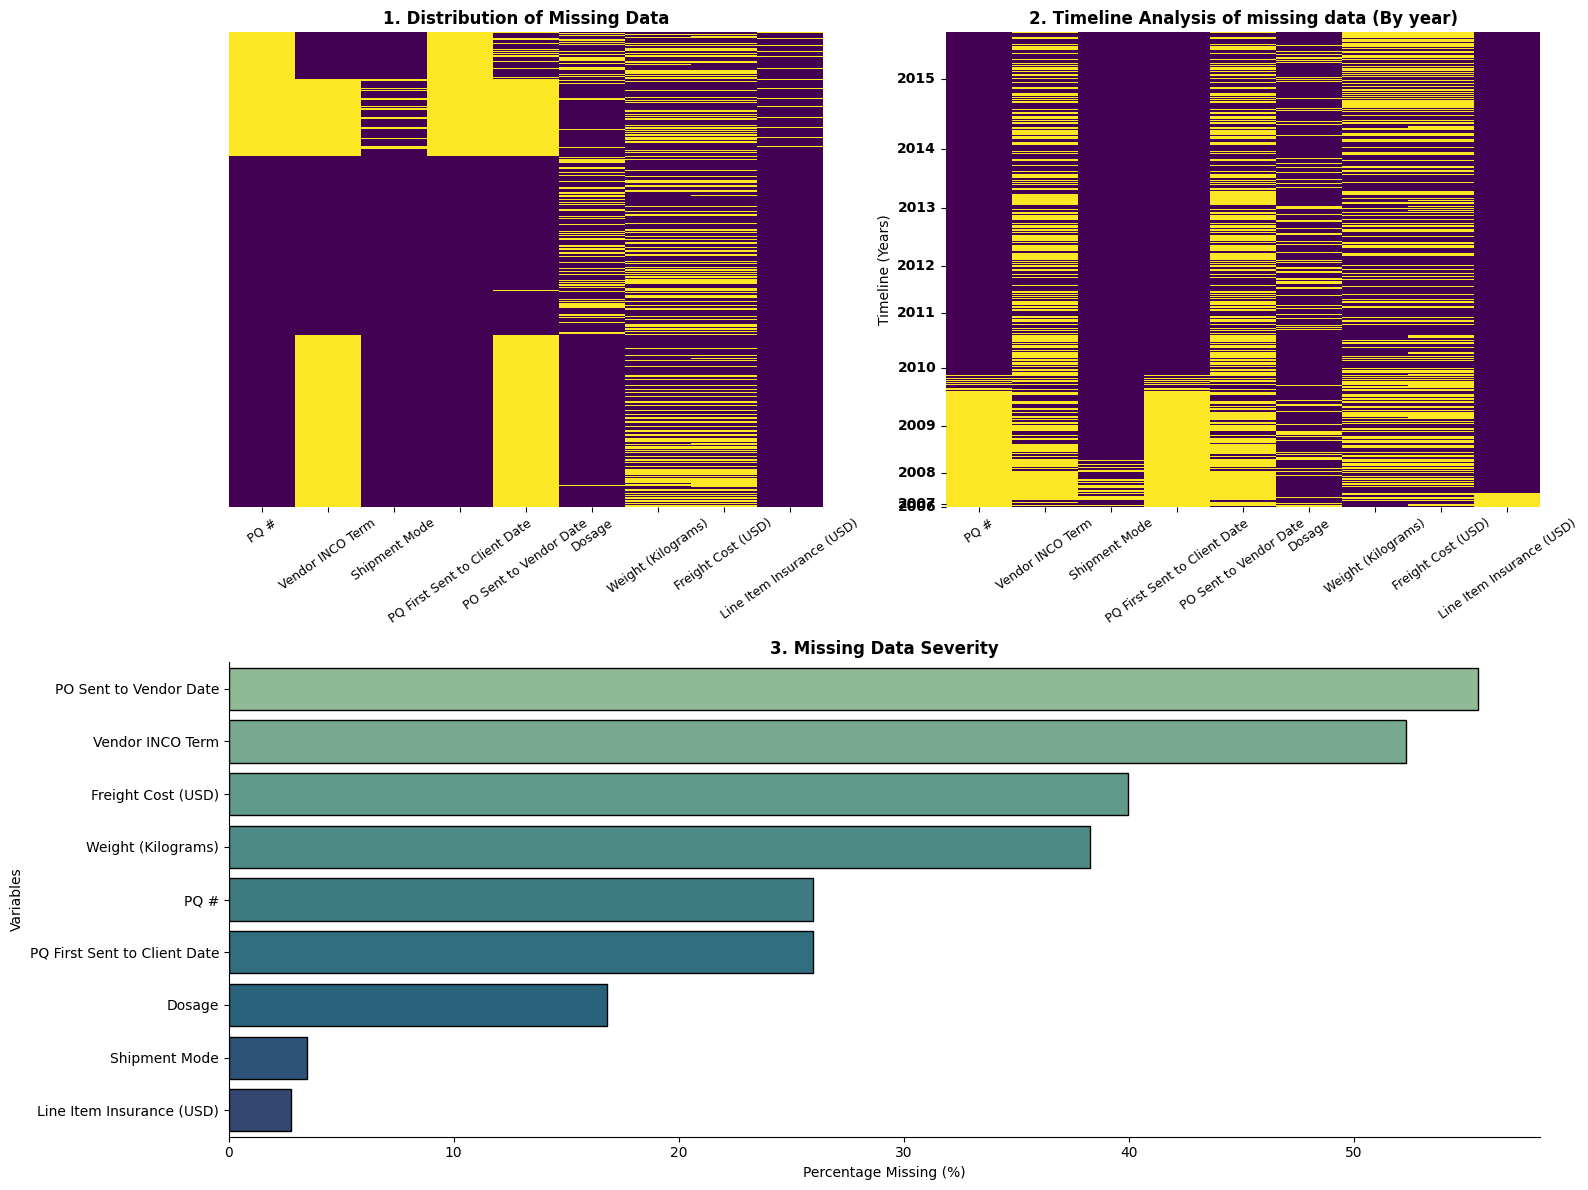

In [245]:
# Creating Layout
fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

#extracting only the columns with null values for clear visualisation
all_null_cols = scms_hidden_nulls.columns[scms_hidden_nulls.isnull().any()].tolist()


# CHART 1: UNSORTED HEATMAP
sns.heatmap(scms_hidden_nulls[all_null_cols].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax1)
ax1.set_title("1. Distribution of Missing Data", fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=35, labelsize=9)

# CHART 2: CHRONOLOGICAL HEATMAP
scms_hidden_nulls['Scheduled Delivery Date'] = pd.to_datetime(scms_hidden_nulls['Scheduled Delivery Date'], errors='coerce')

#prepping the data for sorting the data yearwise
df_clean_dates = scms_hidden_nulls.dropna(subset=['Scheduled Delivery Date'])
df_chronological = df_clean_dates.sort_values(by='Scheduled Delivery Date', ascending=True).reset_index(drop=True)
df_chronological['Year'] = df_chronological['Scheduled Delivery Date'].dt.year
year_positions = df_chronological.groupby('Year').idxmin()['Scheduled Delivery Date']

#plotting the map in chronocological order
sns.heatmap(df_chronological[all_null_cols].isnull(), cbar=False, cmap='viridis', ax=ax2)
ax2.set_yticks(year_positions.values)
ax2.set_yticklabels(year_positions.index, rotation=0, fontweight='bold')
ax2.invert_yaxis()  # Keeps oldest years at the top flowing down
ax2.set_title("2. Timeline Analysis of missing data (By year)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Timeline (Years)")
ax2.tick_params(axis='x', rotation=35, labelsize=9)

# CHART 3: SEVERITY BAR CHART (ALL NULL COLUMNS)

#calculating the % of null values
null_pct = (scms_hidden_nulls.isnull().mean() * 100).reset_index()
null_pct.columns = ['Column', 'Percentage']
null_pct = null_pct[null_pct['Percentage'] > 0].sort_values(by='Percentage', ascending=False)

#horizontal severity comparison bar chart
sns.barplot(x='Percentage', y='Column', data=null_pct, palette='crest', hue='Column', edgecolor='black', ax=ax3)
ax3.set_title("3. Missing Data Severity", fontsize=12, fontweight='bold')
ax3.set_xlabel("Percentage Missing (%)")
ax3.set_ylabel("Variables")
sns.despine(ax=ax3)

plt.tight_layout()
plt.show()

**Insights from visualisation**

**Chart 1 (Missing Value Distribution)**➔ Freight cost and weight nulls are scattered uniformly — other missing data is highly concentrated.

**Chart 2 (Chronological Correlation)** ➔ Concentrated nulls align with pre-2010 timelines — suggests poor data logging standards in legacy records.

**Chart 3 (Missingness Severity)** ➔ Null density peaks in columns containing text placeholders — demands extensive, targeted data cleaning.


### What did you know about your dataset?

*  **End-to-End Scope**: The SCMS dataset provides comprehensive visibility into the global health product supply chain from 2006 to 2015 across 33 variables
*  **Sampling Context**: Non-continuous Order IDs (reaching 86,823) confirm that we are analysing an operational subset rather than a complete transactional archive
*  **Technical Roadblocks**: Qualitative strings such as "Pre-PQ Process" and "Date Not Captured" function as operational nulls, preventing immediate numerical typecasting and timeline analysis
*  **Data Maturity Trend**: Integrity gaps in quotations and insurance are concentrated in records pre-2010, indicating a legacy of inconsistent logging that improved as digital tracking matured
*  **Line-Item Architecture**: Logical duplicates in PO/SO and ASN/DN numbers suggest that orders and shipments are frequently consolidated, containing multiple distinct product line items per transaction
*  **Logistics Metadata**: Detailed shipment modes (Air, Truck, Ocean, Air Charter) and weight references (e.g., "See ASN-...") provide the categorical depth required for a multi-layered analysis of delivery efficiency

## ***2. Understanding Your Variables***

In [246]:
# Dataset Columns
scms_data.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [247]:
# Dataset Describe
scms_data.describe()


,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [248]:
scms_data.describe(include = 'object')

,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD)
count,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,8588,10324,10324,10324,10324,10324
unique,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,54,17,88,2,4688,6733
top,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost
freq,768,2681,67,54,1406,10265,5404,5404,6113,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,990,3532,3172,7030,1507,1442


### Variables Description

* **Wide Volume Range**: Order quantities vary from 1 to 619,999 units, reflecting both small emergency shipments and large-scale replenishments.
* **Pack Size Variability**: Packs range from 1 to 1,000 units, influencing shipment weight and freight costs.
* **Incomplete Insurance Data**: Insurance values reach $7,700, but many records are marked as "Invoiced Separately", limiting total cost visibility.
* **Complex Supply Network**: The dataset spans 142 initiatives, 73 vendors, 88 manufacturing sites, and 43 countries.
* **Potential Delivery Drivers**: High vendor and manufacturing-site diversity may contribute to lead-time variability.
* **Priority Assessment Needed**: Further analysis is required to determine whether First Line Designated products receive faster processing.

### Check Unique Values for each variable.

In [249]:
# Check Unique Values for each variable.
scms_data.nunique().sort_values(ascending = False)

,0
ID,10324
Line Item Value,8741
ASN/DN #,7030
Freight Cost (USD),6733
Line Item Insurance (USD),6722
PO / SO #,6233
Line Item Quantity,5065
Weight (Kilograms),4688
Delivered to Client Date,2093
Delivery Recorded Date,2042


## 3. ***Data Wrangling***

### Data Wrangling Code

Handling Duplicates

In [250]:
item_cols = ['PO / SO #','ASN/DN #', 'Item Description', 'Line Item Quantity','Manufacturing Site','First Line Designation']

#checking for duplication other than critical columns
duplicate_records = scms_data[scms_data.duplicated(subset=item_cols, keep=False)]
print(duplicate_records.sort_values(item_cols))

#dropping 4 columns - complete duplication except ID
scms_data.drop_duplicates(
    subset=item_cols,
    keep='first',
    inplace = True
)

         ID Project Code            PQ #    PO / SO #   ASN/DN #      Country  \
4371  43250   105-SS-T30       FPQ-12623  SCMS-200920  ASN-21751  South Sudan   
5781  68128   105-SS-T30       FPQ-12623  SCMS-200920  ASN-21751  South Sudan   
1126  10692   125-HT-T01  Pre-PQ Process      SO-1291     DN-686        Haiti   
1520  11246   125-HT-T01  Pre-PQ Process      SO-1291     DN-686        Haiti   
2134  12146   100-ZW-T01  Pre-PQ Process       SO-710     DN-488     Zimbabwe   
2135  12147   100-ZW-T01  Pre-PQ Process       SO-710     DN-488     Zimbabwe   
1957  11882   100-ZW-T01  Pre-PQ Process       SO-716     DN-770     Zimbabwe   
2577  12792   100-ZW-T01  Pre-PQ Process       SO-716     DN-770     Zimbabwe   

     Managed By  Fulfill Via Vendor INCO Term Shipment Mode  \
4371   PMO - US  Direct Drop              EXW           Air   
5781   PMO - US  Direct Drop              EXW           Air   
1126   PMO - US     From RDC   N/A - From RDC           Air   
1520   PMO - US   

Handling Missing/Null Values

In [251]:
null_pct = (scms_hidden_nulls.isnull().mean() * 100).round(2).sort_values(ascending=False)

print(null_pct)

PO Sent to Vendor Date          55.52
Vendor INCO Term                52.34
Freight Cost (USD)              39.97
Weight (Kilograms)              38.28
PQ First Sent to Client Date    25.97
PQ #                            25.97
Dosage                          16.82
Shipment Mode                    3.49
Line Item Insurance (USD)        2.78
ID                               0.00
Managed By                       0.00
Country                          0.00
Scheduled Delivery Date          0.00
Fulfill Via                      0.00
ASN/DN #                         0.00
PO / SO #                        0.00
Project Code                     0.00
Sub Classification               0.00
Product Group                    0.00
Delivery Recorded Date           0.00
Delivered to Client Date         0.00
Brand                            0.00
Vendor                           0.00
Molecule/Test Type               0.00
Item Description                 0.00
Line Item Quantity               0.00
Unit of Meas

In [252]:
# 1.Freight cost and weight column "see Id" values are filled with ref Id via INDEX-MATCH in spreadsheet
url = "https://raw.githubusercontent.com/preethipalanisamy12-source/AlmaBetter-Projects/refs/heads/main/SCMS(%20freight%2C%20cost%20resolved).csv"
scms_clean = pd.read_csv(url)

scms_clean.drop(columns = ['Weight (Kilograms)','Freight Cost (USD)'], inplace = True)
scms_clean

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Line Item Insurance (USD),Freight Cost resolved,Weight resolved
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,NaN,780.34,13
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,NaN,4521.5,358
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,NaN,1653.78,171
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,NaN,16007.06,1855
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,NaN,45450.08,7590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,10/16/14,N/A - From RDC,31-Jul-15,15-Jul-15,20-Jul-15,ARV,Pediatric,SCMS from RDC,"Lamivudine/Nevirapine/Zidovudine 30/50/60mg, d...",Lamivudine/Nevirapine/Zidovudine,Generic,30/50/60mg,Chewable/dispersible tablet - FDC,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,705.79,46111.55,25880
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,10/24/14,N/A - From RDC,31-Jul-15,6-Aug-15,7-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,161.71,14734.92,4426
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,8/12/14,N/A - From RDC,31-Aug-15,25-Aug-15,3-Sep-15,ARV,Adult,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Generic,600/300/300mg,Tablet - FDC,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,5284.04,Freight Included in Commodity Cost,Weight Captured Separately
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,7/1/15,N/A - From RDC,9-Sep-15,4-Aug-15,11-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,134.03,Freight I

In [253]:
# 2.dropping dosage column - not in scope of logistics analysis
scms_clean.drop(columns = ['Dosage'], inplace = True)


In [254]:
# 3.PO Sent to Vendor Date placeholders kept as Nan
scms_clean['PO Sent to Vendor Date'].replace(
    ['Date Not Captured', 'N/A - From RDC'],np.nan, inplace = True)

/tmp/ipykernel_6350/245238952.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  scms_clean['PO Sent to Vendor Date'].replace(


In [255]:
# 4.shipment NaNs with mode based on Country.
mode_fill = scms_clean.groupby(['Country','Fulfill Via'])['Shipment Mode'] \
              .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
scms_clean['Shipment Mode'] = scms_clean['Shipment Mode'].fillna(mode_fill)

In [256]:
# 5.Finding the insurance according to the value of the item.
# Replacing the missing values with meadian of that insurance value.

ratio = (scms_clean.loc[scms_clean['Line Item Insurance (USD)']>0, 'Line Item Insurance (USD)'] /
         scms_clean.loc[scms_clean['Line Item Insurance (USD)']>0, 'Line Item Value']).median()
missing_insurance = scms_clean['Line Item Insurance (USD)'].isna()
scms_clean.loc[missing_insurance, 'Line Item Insurance (USD)'] = scms_clean.loc[missing_insurance, 'Line Item Value'] * ratio

In [257]:
# 6. Converting other placeholders to null as they can't be logically imputed.
placeholders = ['Pre-PQ Process', 'Date Not Captured', 'Weight Captured Separately',
                'Invoiced Separately', 'Freight Included in Commodity Cost', 'N/A - From RDC']
scms_clean.replace(placeholders, np.nan, inplace = True)

scms_clean.isnull().sum().sort_values(ascending = False)

,0
PO Sent to Vendor Date,5732
Vendor INCO Term,5404
PQ #,2681
PQ First Sent to Client Date,2681
Freight Cost resolved,1786
Weight resolved,1633
ASN/DN #,0
ID,0
Fulfill Via,0
Managed By,0


In [258]:
# 7. INCO term - handling missing values
print(scms_clean['Vendor INCO Term'].isnull().mean()*100)


scms_clean['PO Sent to Vendor Date'] = pd.to_datetime(scms_clean['PO Sent to Vendor Date'], errors='coerce')

scms_clean['Year'] = scms_clean['PO Sent to Vendor Date'].dt.year
scms_clean.groupby('Year')['Vendor INCO Term'] \
          .apply(lambda x: x.isna().mean()*100) \
          .round(2)

#Vendor INCO Term contained 52.34% missing values.
#Missingness remained high across all years, including the most recent years (>35%).
#No sufficiently complete time period was identified for reliable subset analysis.

scms_clean.drop(columns = ['Vendor INCO Term'], inplace = True)

/tmp/ipykernel_6350/2574464439.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  scms_clean['PO Sent to Vendor Date'] = pd.to_datetime(scms_clean['PO Sent to Vendor Date'], errors='coerce')


52.34405269275475


Type Casting


In [259]:
# Date columns
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date',
             'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']

for col in date_cols:
    scms_clean[col] = pd.to_datetime(scms_clean[col], errors='coerce')

# Numeric columns stored as text
num_cols = ['Freight Cost resolved', 'Weight resolved ']

for col in num_cols:
    scms_clean[col] = pd.to_numeric(scms_clean[col], errors='coerce')

print(scms_clean.dtypes)

/tmp/ipykernel_6350/1680575892.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  scms_clean[col] = pd.to_datetime(scms_clean[col], errors='coerce')
/tmp/ipykernel_6350/1680575892.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  scms_clean[col] = pd.to_datetime(scms_clean[col], errors='coerce')
/tmp/ipykernel_6350/1680575892.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  scms_clean[col] = pd.to_datetime(scms_clean[col], errors='coerce')
/tmp/ipykernel_6350/1680575892.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling bac

ID                                       int64
Project Code                            object
PQ #                                    object
PO / SO #                               object
ASN/DN #                                object
Country                                 object
Managed By                              object
Fulfill Via                             object
Shipment Mode                           object
PQ First Sent to Client Date    datetime64[ns]
PO Sent to Vendor Date          datetime64[ns]
Scheduled Delivery Date         datetime64[ns]
Delivered to Client Date        datetime64[ns]
Delivery Recorded Date          datetime64[ns]
Product Group                           object
Sub Classification                      object
Vendor                                  object
Item Description                        object
Molecule/Test Type                      object
Brand                                   object
Dosage Form                             object
Unit of Measu

Renaming selected columns for improved readability and cleaner visualizations.

In [260]:
scms_clean = scms_clean.rename(columns={
    'PQ First Sent to Client Date': 'PQ_Sent_Date',
    'PO Sent to Vendor Date': 'PO_Sent_Date',
    'Delivered to Client Date': 'Delivered_Date',
    'Line Item Quantity' : 'Quantity',
    'Line Item Value' : 'Value',
    'Weight resolved ': 'Weight_KG',
    'Freight Cost resolved': 'Freight_Cost_USD',
    'Line Item Insurance (USD)': 'Insurance_USD'
})

In [261]:
scms_clean.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Shipment Mode', 'PQ_Sent_Date',
       'PO_Sent_Date', 'Scheduled Delivery Date', 'Delivered_Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Quantity', 'Value',
       'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Insurance_USD', 'Freight_Cost_USD',
       'Weight_KG', 'Year'],
      dtype='object')

Handling Outliers

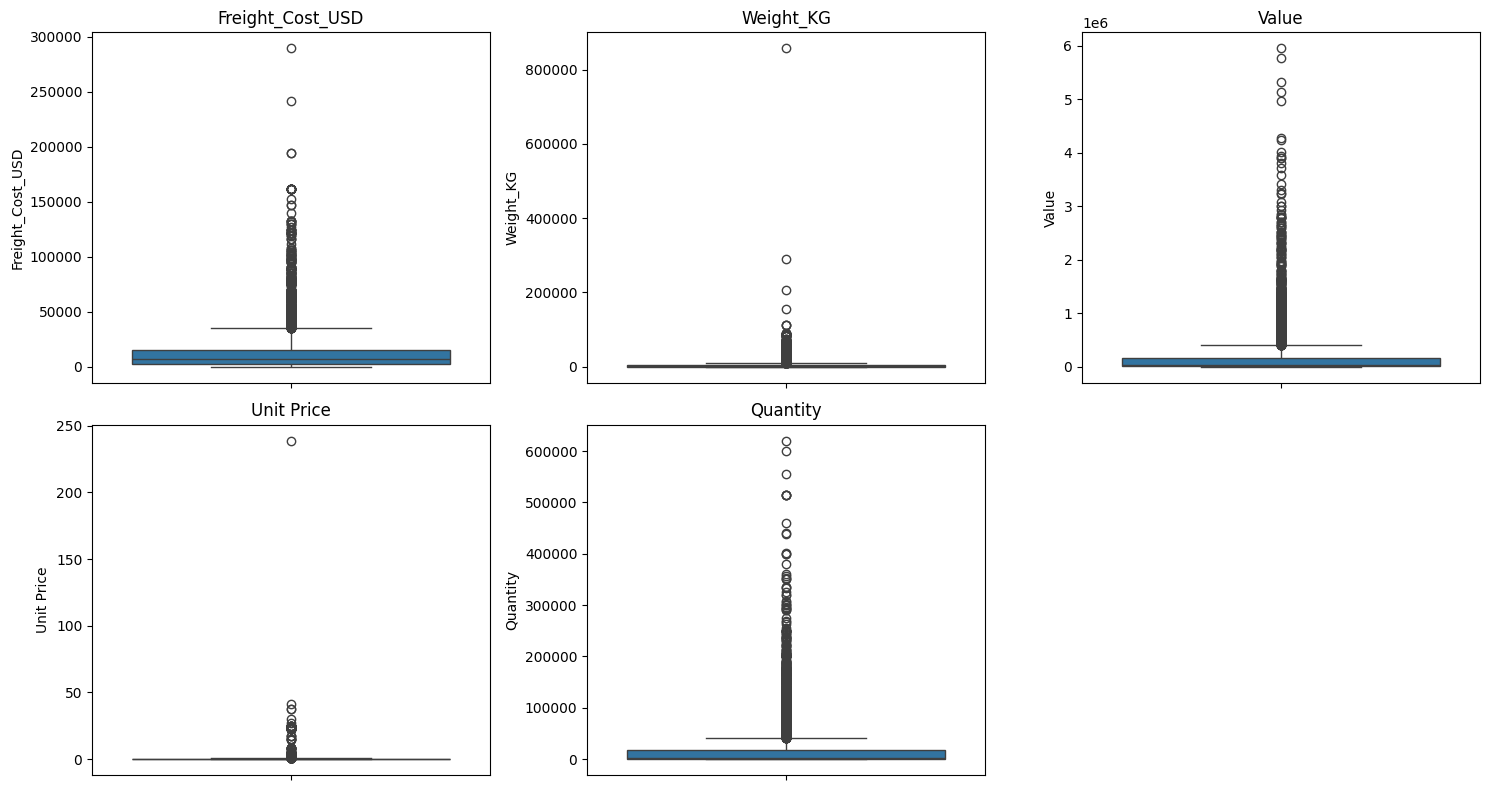

In [262]:
num_cols = [
    'Freight_Cost_USD',
    'Weight_KG',
    'Value',
    'Unit Price',
    'Quantity'
]

plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=scms_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

* Freight Cost & Weight: A few exceptionally large shipments drive extreme values.
* Line Value: Contains several high-value procurement orders.
* Unit Price: Most items are low-cost, with a few premium products.
* Quantity: Bulk purchases create very large order volumes.

**Overall**: All variables likely representing genuine large-scale supply chain transactions rather than data errors.

Data Validation

In [263]:
#looking for dates where delivered date is lesser than the Purchase Order date.
illogical_dates = scms_clean['Delivered_Date'] < scms_clean['PO_Sent_Date']
scms_clean.loc[
    illogical_dates,
    ['PO_Sent_Date', 'Delivered_Date', 'Country', 'Vendor', 'Fulfill Via']
].head(20)

,PO_Sent_Date,Delivered_Date,Country,Vendor,Fulfill Via
454,2008-04-28,2008-01-03,Haiti,REINBOLD EXPORT IMPORT,Direct Drop
1637,2007-11-12,2007-01-24,South Africa,"JSI R&T INSTITUTE, INC.",Direct Drop
2698,2014-06-23,2014-01-14,Dominican Republic,"ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...",Direct Drop
3387,2015-05-29,2015-05-26,South Africa,PHARMACY DIRECT,Direct Drop
4906,2014-06-26,2014-06-25,South Africa,PHARMACY DIRECT,Direct Drop


In [264]:
#keeping illogical dates as null.
scms_clean.loc[illogical_dates, 'Delivered_Date'] = np.nan

In [265]:
for col in ['Unit Price', 'Pack Price', 'Value']:
    zero_count = (scms_clean[col] == 0).sum()
    print(col, '- zero value rows:', zero_count)

# numeric cols - price, value has 0 values - donated or non-commercial shipments
# keeping as it is

Unit Price - zero value rows: 103
Pack Price - zero value rows: 18
Value - zero value rows: 17


### What all manipulations have you done and insights you found?

### Data Wrangling & Key Insights

* **Duplicate Handling:** Investigated repeated POs and ASNs, distinguished legitimate multi-line and split-shipment records from true duplicates, and removed only confirmed duplicate entries.
* **Missing Value Treatment:** Replaced placeholder texts with `NaN`, recovered freight cost and weight from ASN references, imputed missing Shipment Mode using business logic, and retained genuine unknown values. Dropped **Vendor INCO Term** due to excessive missingness (>50%).
* **Type Casting:** Converted date columns to datetime format and cost, quantity, weight, and insurance fields to numeric types for accurate calculations.
* **Column Renaming:** Simplified lengthy column names to improve readability and reduce clutter in visualizations.
* **Outlier Assessment:** Identified extreme values using boxplots and retained them, as they represent genuine bulk procurements, large shipments, and high-value transactions.
* **Data Validation:** Checked for temporal inconsistencies and corrected 5 records where delivery dates occurred before PO sent dates.

**Key Insight:** The dataset reflects real-world humanitarian supply chain operations, including multi-line procurement orders, shipment-level cost references, large-scale bulk movements, and a small number of zero-value transactions likely representing donated or non-commercial shipments.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Data Transformation for Data Visualisation

In [266]:
# Copy for visualization-ready dataset
scms_viz = scms_clean.copy()

# --- Derived columns: delivery timeline ---
scms_viz['Lead_Time_Days'] = (scms_viz['Delivered_Date'] - scms_viz['PO_Sent_Date']).dt.days
scms_viz['Delivery_Delay_Days'] = (scms_viz['Delivered_Date'] - scms_viz['Scheduled Delivery Date']).dt.days
scms_viz['On_Time_Flag'] = scms_viz['Delivered_Date'] <= scms_viz['Scheduled Delivery Date']
scms_viz['Procurement_Days'] = (scms_viz['PO_Sent_Date'] - scms_viz['PQ_Sent_Date']).dt.days
scms_viz['Reporting_Lag_Days'] = (scms_viz['Delivery Recorded Date'] - scms_viz['Delivered_Date']).dt.days

# --- Derived columns: cost efficiency ---
scms_viz['Freight_Cost_Per_KG'] = scms_viz['Freight_Cost_USD'] / scms_viz['Weight_KG']
scms_viz['Freight_Pct_of_Value'] = scms_viz['Freight_Cost_USD'] / scms_viz['Value']
scms_viz['Total_Landed_Cost'] = (
    scms_viz['Value'] +
    scms_viz['Freight_Cost_USD'] +
    scms_viz['Insurance_USD']
)

# --- Derived columns: trend ---
scms_viz['Order_Year'] = scms_viz['PO_Sent_Date'].dt.year
scms_viz['Order_Month'] = scms_viz['PO_Sent_Date'].dt.month
scms_viz['Order_Quarter'] = scms_viz['PO_Sent_Date'].dt.quarter

# --- Derived columns: segmentation ---
scms_viz['Order_Size_Category'] = pd.cut(
    scms_viz['Quantity'],
    bins=[0, 1000, 10000, float('inf')],
    labels=['Small', 'Medium', 'Large']
)

# Dropping columns not needed for supply chain analysis
drop_cols = [
    'Project Code',
    'PQ #',
    'PO / SO #',
    'ASN/DN #',
    'Item Description',
    'Molecule/Test Type',
    'Brand',
    'Dosage Form'
]

scms_viz = scms_viz.drop(columns=drop_cols)

print(scms_viz.shape)
print(scms_viz.columns.tolist())

(10324, 36)
['ID', 'Country', 'Managed By', 'Fulfill Via', 'Shipment Mode', 'PQ_Sent_Date', 'PO_Sent_Date', 'Scheduled Delivery Date', 'Delivered_Date', 'Delivery Recorded Date', 'Product Group', 'Sub Classification', 'Vendor', 'Unit of Measure (Per Pack)', 'Quantity', 'Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Insurance_USD', 'Freight_Cost_USD', 'Weight_KG', 'Year', 'Lead_Time_Days', 'Delivery_Delay_Days', 'On_Time_Flag', 'Procurement_Days', 'Reporting_Lag_Days', 'Freight_Cost_Per_KG', 'Freight_Pct_of_Value', 'Total_Landed_Cost', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_Size_Category']


In [282]:
scms_viz.to_csv('scms_viz.csv')

#### Chart - 1

In [267]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [268]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [269]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [270]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [271]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [272]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [273]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [274]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [275]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [276]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [277]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [278]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [279]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [280]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [281]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***